# Unsupervised training notebook for `model.ipynb`

This notebook:
- imports the model definitions you already wrote in `model.ipynb`
- uses `UnsupervisedSegmentationUNet`
- trains on a random subset of 500 downloaded images from `train_dataset.json`
- saves checkpoints and a loss history


In [33]:
import json
import random
import re
from pathlib import Path

import numpy as np
from PIL import Image

import torch
torch.cuda.empty_cache() 
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from tqdm.auto import tqdm

In [34]:
# paths / config
MODEL_NOTEBOOK = Path("./model.ipynb")
TRAIN_JSON = Path("C:\\Users\\divya\\OneDrive\\Documents\\UMICH\\504\\504FinalProject\\unsup_sup_notebooks\\train_dataset.json")
IMAGE_ROOT = Path("C:\\Users\\divya\\OneDrive\\Documents\\UMICH\\504\\504FinalProject\\kaggle\\training_dataset")   # folder containing downloaded images

CFG = {
    "subset_size": 300,
    "image_size": 256,
    "batch_size": 8,
    "epochs": 20,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "num_workers": 0,
    "seed": 42,
    "base_channels": 64,
    "num_clusters": 2,   # FG/BG only
    "recon_weight": 1.0,
    "smooth_weight": 0.1,
    "entropy_weight": 0.1,
    "balance_weight": 0.3,
    "save_dir": "./unsup_ckpts",
}


In [35]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG["seed"])
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [36]:
# load only the definitions we need from model.ipynb
NEEDED_NAMES = {
    "DoubleConv",
    "DownSample",
    "Encoder",
    "UpBlock",
    "Decoder",
    "UnsupervisedSegmentationUNet",
}

def load_defs_from_notebook(nb_path, needed_names):
    with open(nb_path, "r", encoding="utf-8") as f:
        nb = json.load(f)

    namespace = {}
    kept_cells = []

    for cell in nb["cells"]:
        if cell["cell_type"] != "code":
            continue

        src = "".join(cell["source"])
        stripped = src.lstrip()

        if stripped.startswith("import ") or stripped.startswith("from "):
            kept_cells.append(src)
            continue

        if any(re.search(rf"^(class|def)\s+{name}\b", src, flags=re.M) for name in needed_names):
            kept_cells.append(src)

    for src in kept_cells:
        exec(src, namespace)

    return namespace

ns = load_defs_from_notebook(MODEL_NOTEBOOK, NEEDED_NAMES)
UnsupervisedSegmentationUNet = ns["UnsupervisedSegmentationUNet"]

print("Loaded:", sorted(NEEDED_NAMES))


Loaded: ['Decoder', 'DoubleConv', 'DownSample', 'Encoder', 'UnsupervisedSegmentationUNet', 'UpBlock']


In [37]:
# dataset that uses only downloaded local images
def load_coco_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

class FathomNetImageDataset(Dataset):
    def __init__(self, json_path, image_root, image_size=256):
        coco = load_coco_json(json_path)
        self.images = coco["images"]
        self.image_root = Path(image_root)
        self.image_size = image_size

        # keep only images that exist locally
        self.images = [
            info for info in self.images
            if (self.image_root / info["file_name"]).exists()
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        info = self.images[idx]
        path = self.image_root / info["file_name"]

        img = Image.open(path).convert("RGB")
        img = img.resize((self.image_size, self.image_size), Image.BILINEAR)
        img = np.asarray(img, dtype=np.float32) / 255.0
        img = torch.from_numpy(img).permute(2, 0, 1)

        # normalize to [-1, 1] to stabilize reconstruction-based training
        img = img * 2.0 - 1.0

        return {
            "image": img,
            "image_id": info["id"],
            "file_name": info["file_name"],
        }

full_dataset = FathomNetImageDataset(
    json_path=TRAIN_JSON,
    image_root=IMAGE_ROOT,
    image_size=CFG["image_size"],
)

print("available local images:", len(full_dataset))


available local images: 6463


In [38]:
# choose only a random subset of 500 images
subset_size = min(CFG["subset_size"], len(full_dataset))
indices = list(range(len(full_dataset)))
random.Random(CFG["seed"]).shuffle(indices)
subset_indices = indices[:subset_size]

train_dataset = Subset(full_dataset, subset_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=True,
)

print("subset used for training:", len(train_dataset))


subset used for training: 300


In [39]:
model = UnsupervisedSegmentationUNet(
    in_channels=3,
    base_channels=CFG["base_channels"],
    num_clusters=CFG["num_clusters"],
    recon_weight=CFG["recon_weight"],
    smooth_weight=CFG["smooth_weight"],
    entropy_weight=CFG["entropy_weight"],
    balance_weight=CFG["balance_weight"],
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"],
)

Path(CFG["save_dir"]).mkdir(parents=True, exist_ok=True)

model


UnsupervisedSegmentationUNet(
  (encoder): Encoder(
    (inc): DoubleConv(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (down1): DownSample(
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (conv): DoubleConv(
        (block): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(

In [40]:
def train_one_epoch(model, loader, optimizer, device, epoch=None, total_epochs=None):
    model.train()

    running = {
        "loss": 0.0,
        "recon_loss": 0.0,
        "smooth_loss": 0.0,
        "entropy_loss": 0.0,
        "balance_loss": 0.0,
    }

    n_batches = 0

    if epoch is None:
        desc = "Train"
    else:
        desc = f"Train Epoch {epoch}/{total_epochs}"

    batch_bar = tqdm(loader, desc=desc, leave=False)

    for batch in batch_bar:
        x = batch["image"].to(device, non_blocking=True)
        # print("training now")

        out = model(x, compute_loss=True)
        loss = out["loss"]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running["loss"] += loss.item()
        running["recon_loss"] += out["recon_loss"].item()
        running["smooth_loss"] += out["smooth_loss"].item()
        running["entropy_loss"] += out["entropy_loss"].item()
        running["balance_loss"] += out["balance_loss"].item()
        n_batches += 1

        batch_bar.set_postfix({
            "loss": f"{running['loss']/n_batches:.4f}",
            "recon": f"{running['recon_loss']/n_batches:.4f}",
            "smooth": f"{running['smooth_loss']/n_batches:.4f}",
            "entropy": f"{running['entropy_loss']/n_batches:.4f}",
            "balance": f"{running['balance_loss']/n_batches:.4f}",
        })

    for k in running:
        running[k] /= max(n_batches, 1)

    return running

In [41]:
history = []
best_loss = float("inf")

epoch_bar = tqdm(range(1, CFG["epochs"] + 1), desc="Epochs")

for epoch in epoch_bar:
    metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device,
        epoch=epoch,
        total_epochs=CFG["epochs"],
    )

    history.append({"epoch": epoch, **metrics})

    epoch_bar.set_postfix({
        "loss": f"{metrics['loss']:.4f}",
        "recon": f"{metrics['recon_loss']:.4f}",
        "smooth": f"{metrics['smooth_loss']:.4f}",
    })

    print(
        f"Epoch {epoch:02d} | "
        f"loss={metrics['loss']:.4f} | "
        f"recon={metrics['recon_loss']:.4f} | "
        f"smooth={metrics['smooth_loss']:.4f} | "
        f"entropy={metrics['entropy_loss']:.4f} | "
        f"balance={metrics['balance_loss']:.4f}"
    )

    ckpt = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "cfg": CFG,
        "history": history,
    }

    torch.save(ckpt, Path(CFG["save_dir"]) / "last_unsup_model.pt")

    if metrics["loss"] < best_loss:
        best_loss = metrics["loss"]
        torch.save(ckpt, Path(CFG["save_dir"]) / "best_unsup_model.pt")
        print("saved best model")

Epochs:   0%|          | 0/20 [00:51<?, ?it/s, loss=0.2951, recon=0.4473, smooth=0.0337]

Epoch 01 | loss=0.2951 | recon=0.4473 | smooth=0.0337 | entropy=0.3462 | balance=-0.6340


Epochs:   5%|▌         | 1/20 [00:51<16:27, 52.00s/it, loss=0.2951, recon=0.4473, smooth=0.0337]

saved best model


Epochs:   5%|▌         | 1/20 [01:44<16:27, 52.00s/it, loss=0.2479, recon=0.4024, smooth=0.0298]

...

saved best model


Epochs:  95%|█████████▌| 19/20 [18:44<00:54, 54.06s/it, loss=0.0222, recon=0.1791, smooth=0.0545]

Epoch 20 | loss=0.0222 | recon=0.1791 | smooth=0.0545 | entropy=0.2848 | balance=-0.6362


Epochs: 100%|██████████| 20/20 [18:45<00:00, 56.25s/it, loss=0.0222, recon=0.1791, smooth=0.0545]

saved best model


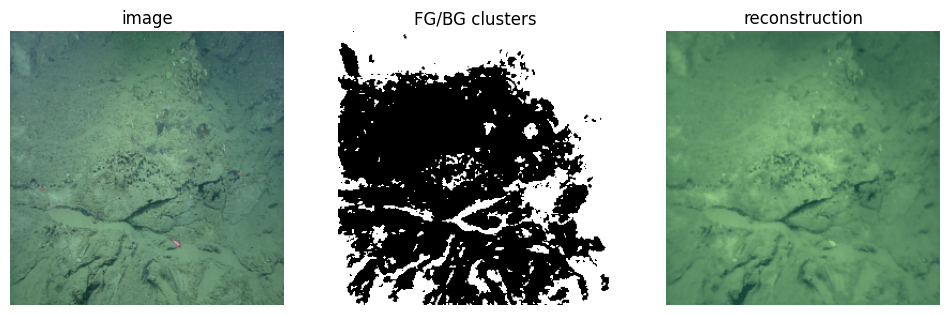

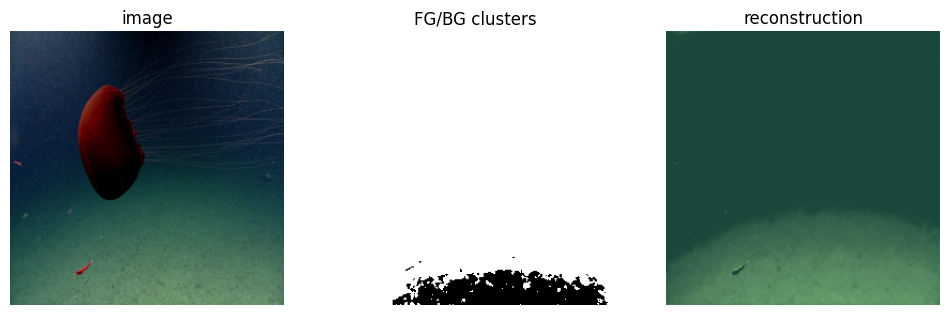

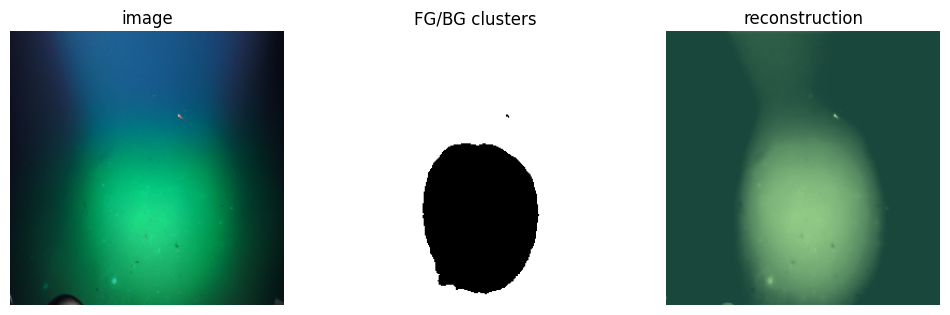

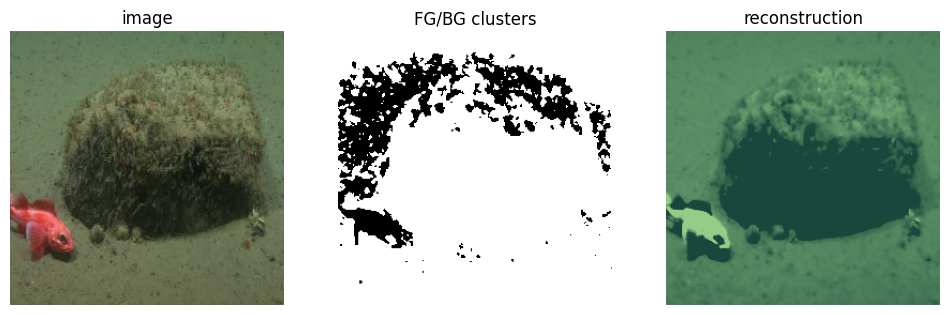

In [42]:
import matplotlib.pyplot as plt

model.eval()
batch = next(iter(train_loader))
x = batch["image"][:7].to(device)

with torch.no_grad():
    out = model(x, compute_loss=False)

segment_ids = out["segment_ids"].cpu().numpy()
recon = out["reconstruction"].cpu()

x_vis = ((x.cpu() + 1.0) / 2.0).clamp(0, 1)
recon_vis = ((recon + 1.0) / 2.0).clamp(0, 1)

for i in range(min(4, x_vis.shape[0])):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(x_vis[i].permute(1, 2, 0))
    plt.title("image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(segment_ids[i], cmap="gray")
    plt.title("FG/BG clusters")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(recon_vis[i].permute(1, 2, 0))
    plt.title("reconstruction")
    plt.axis("off")

    plt.show()